# Neuronale Netze in TensorFlow: Konfiguration, Tuning & Regularisierung

Ein praktischer Leitfaden mit Beispielen.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Daten laden
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

---
## 1. Architektur-Parameter

Die grundlegenden Stellschrauben deines Netzwerks.

### 1.1 Anzahl und Größe der Layer

In [2]:
# Klein: Schnell, aber begrenzte Kapazität
model_small = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Mittel: Gute Balance
model_medium = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Groß: Mehr Kapazität, aber Overfitting-Gefahr
model_large = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

print(f'Klein:  {model_small.count_params():,} Parameter')
print(f'Mittel: {model_medium.count_params():,} Parameter')
print(f'Groß:   {model_large.count_params():,} Parameter')

Klein:  50,890 Parameter
Mittel: 109,386 Parameter
Groß:   567,434 Parameter


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 1.2 Aktivierungsfunktionen

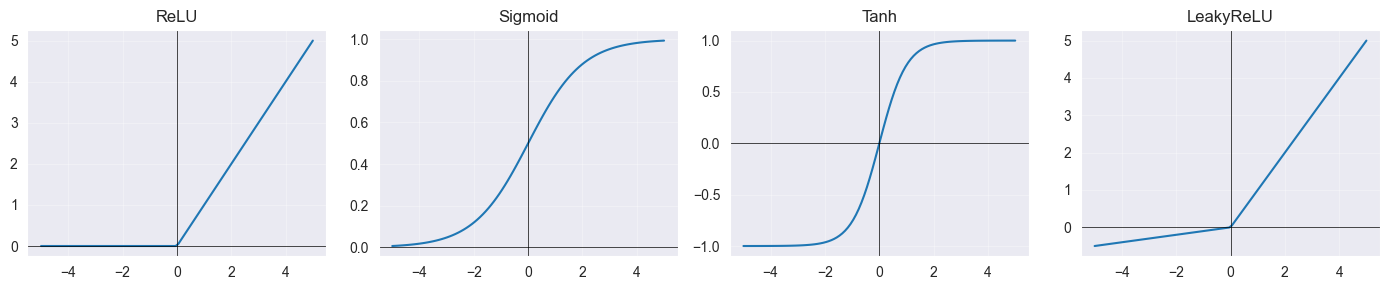

In [3]:
# Visualisierung der Aktivierungsfunktionen
x = np.linspace(-5, 5, 100)

activations = {
    'ReLU': np.maximum(0, x),
    'Sigmoid': 1 / (1 + np.exp(-x)),
    'Tanh': np.tanh(x),
    'LeakyReLU': np.where(x > 0, x, 0.1 * x),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x, y)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

In [4]:
# Verwendung im Modell
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    
    # Standard: ReLU (schnell, funktioniert meist gut)
    tf.keras.layers.Dense(128, activation='relu'),
    
    # Alternative: LeakyReLU (verhindert "tote" Neuronen)
    tf.keras.layers.Dense(64),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    
    # Ausgabe: Softmax für Klassifikation
    tf.keras.layers.Dense(10, activation='softmax')
])

**Empfehlungen:**

| Aktivierung | Wann verwenden |
|-------------|----------------|
| `relu` | Standard für Hidden Layers |
| `leaky_relu` | Wenn ReLU "tote" Neuronen produziert |
| `sigmoid` | Binäre Klassifikation (Output) |
| `softmax` | Multi-Klassen Klassifikation (Output) |
| `linear`/None | Regression (Output) |

---
## 2. Regularisierung

Techniken gegen Overfitting.

### 2.1 Dropout

In [5]:
# Dropout deaktiviert zufällig Neuronen während des Trainings
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),  # 30% ausschalten
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),  # 20% ausschalten
    tf.keras.layers.Dense(10, activation='softmax')
])

# Typische Werte: 0.2-0.5
# Höher = stärkere Regularisierung

### 2.2 L1/L2 Regularisierung (Weight Decay)

In [6]:
from tensorflow.keras import regularizers

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    
    # L2: Bestraft große Gewichte (häufigste Wahl)
    tf.keras.layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001)),
    
    # L1: Führt zu spärlichen Gewichten (viele Nullen)
    tf.keras.layers.Dense(64, activation='relu',
                          kernel_regularizer=regularizers.l1(0.001)),
    
    # L1+L2 kombiniert (Elastic Net)
    tf.keras.layers.Dense(32, activation='relu',
                          kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    
    tf.keras.layers.Dense(10, activation='softmax')
])

# Typische Werte: 0.0001 - 0.01

### 2.3 Batch Normalization

In [7]:
# BatchNorm normalisiert die Aktivierungen zwischen Layern
# -> Stabileres Training, höhere Learning Rates möglich

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),  # Nach Dense, vor Aktivierung
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(64),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    
    tf.keras.layers.Dense(10, activation='softmax')
])

### 2.4 Early Stopping

In [8]:
# Stoppt Training wenn Validierung nicht mehr besser wird
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',      # Was überwachen
    patience=3,              # Epochen ohne Verbesserung
    restore_best_weights=True  # Beste Gewichte wiederherstellen
)

# Verwendung:
# model.fit(..., callbacks=[early_stopping])

---
## 3. Optimizer & Learning Rate

Wie das Netzwerk lernt.

### 3.1 Optimizer-Vergleich

In [9]:
# SGD: Einfach, braucht mehr Tuning
opt_sgd = tf.keras.optimizers.SGD(learning_rate=0.01)

# SGD mit Momentum: Schnellere Konvergenz
opt_sgd_momentum = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

# Adam: Adaptiv, meist beste Wahl
opt_adam = tf.keras.optimizers.Adam(learning_rate=0.001)

# AdamW: Adam mit Weight Decay (gut gegen Overfitting)
opt_adamw = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01)

# RMSprop: Gut für RNNs
opt_rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001)

**Empfehlung:** Starte mit `Adam(learning_rate=0.001)`, das funktioniert in 90% der Fälle.

### 3.2 Learning Rate anpassen

In [10]:
# Automatisch reduzieren wenn Plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # LR halbieren
    patience=2,       # Nach 2 Epochen ohne Verbesserung
    min_lr=1e-6       # Minimale LR
)

# Oder: Learning Rate Schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
opt_scheduled = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

### 3.3 Learning Rate Finder

In [11]:
def find_learning_rate(model, x_train, y_train, start_lr=1e-7, end_lr=1, epochs=1):
    """Findet optimale Learning Rate durch exponentielles Erhöhen."""
    
    # Modell kopieren
    model_copy = tf.keras.models.clone_model(model)
    model_copy.set_weights(model.get_weights())
    
    num_batches = len(x_train) // 32
    lr_mult = (end_lr / start_lr) ** (1 / num_batches)
    
    lrs, losses = [], []
    lr = start_lr
    
    model_copy.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy'
    )
    
    for i in range(num_batches):
        batch_x = x_train[i*32:(i+1)*32]
        batch_y = y_train[i*32:(i+1)*32]
        
        loss = model_copy.train_on_batch(batch_x, batch_y)
        
        lrs.append(lr)
        losses.append(loss)
        
        lr *= lr_mult
        model_copy.optimizer.learning_rate.assign(lr)
        
        if loss > losses[0] * 4:  # Stop wenn Loss explodiert
            break
    
    # Plot
    plt.figure(figsize=(10, 4))
    plt.semilogx(lrs, losses)
    plt.xlabel('Learning Rate')
    plt.ylabel('Loss')
    plt.title('Learning Rate Finder')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Empfehlung: LR wo Loss am steilsten fällt
    min_loss_idx = np.argmin(losses)
    suggested_lr = lrs[min_loss_idx] / 10
    print(f'Empfohlene Learning Rate: {suggested_lr:.6f}')
    return suggested_lr

# Beispiel (auskommentiert da zeitintensiv):
# model_test = tf.keras.Sequential([...])
# best_lr = find_learning_rate(model_test, x_train, y_train)

---
## 4. Batch Size

In [12]:
# Kleine Batch Size (16-32)
# + Bessere Generalisierung
# + Weniger Speicher
# - Langsamer, mehr Rauschen

# Große Batch Size (128-512)
# + Schnelleres Training
# + Stabilere Gradienten
# - Kann schlechter generalisieren
# - Mehr Speicher

# Empfehlung: 32-128 für die meisten Fälle
BATCH_SIZE = 64

---
## 5. Komplettes Beispiel mit allen Techniken

In [13]:
def create_tuned_model():
    """Gut konfiguriertes Modell mit Regularisierung."""
    
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        
        # Layer 1
        tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.3),
        
        # Layer 2
        tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.2),
        
        # Output
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2
    )
]

# Training
model = create_tuned_model()
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,  # Early Stopping beendet früher
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9033 - loss: 0.6272 - val_accuracy: 0.9648 - val_loss: 0.3319 - learning_rate: 0.0010
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9457 - loss: 0.3522 - val_accuracy: 0.9685 - val_loss: 0.2532 - learning_rate: 0.0010
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9519 - loss: 0.2951 - val_accuracy: 0.9735 - val_loss: 0.2168 - learning_rate: 0.0010
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9545 - loss: 0.2732 - val_accuracy: 0.9707 - val_loss: 0.2252 - learning_rate: 0.0010
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9552 - loss: 0.2655 - val_accuracy: 0.9740 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9671 - loss: 0.2128 - val_accuracy: 0.9818 - val_loss: 0.1622 - learning_rate: 5.0000e-04
Epoch 7/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9691 - loss: 0.191

Test Accuracy: 98.70%


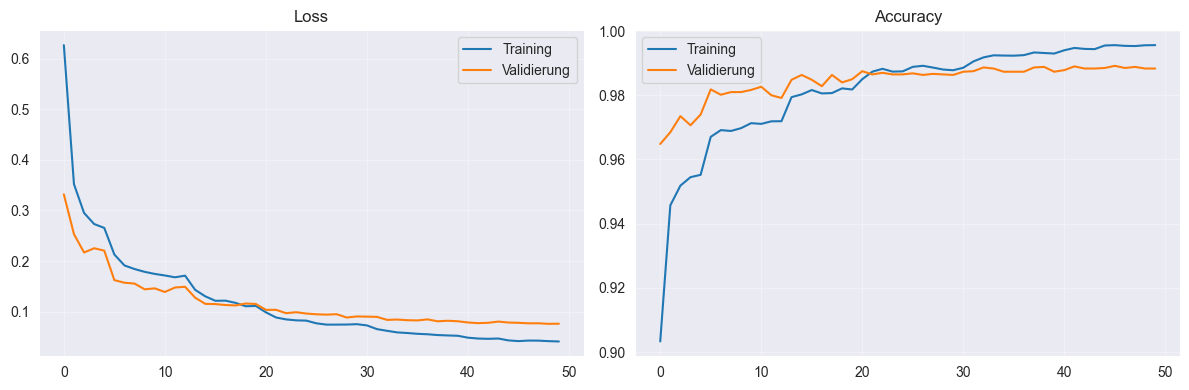

In [14]:
# Ergebnis
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')

# Trainingsverlauf
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validierung')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validierung')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Zusammenfassung: Tuning-Checkliste

| Problem | Lösung |
|---------|--------|
| **Overfitting** (Val-Loss steigt) | Dropout ↑, L2 ↑, Early Stopping, weniger Layer |
| **Underfitting** (beide Losses hoch) | Mehr Layer/Neuronen, weniger Regularisierung |
| **Training instabil** | Learning Rate ↓, BatchNorm hinzufügen |
| **Training zu langsam** | Learning Rate ↑, Batch Size ↑ |
| **Loss explodiert** | Learning Rate ↓, Gradient Clipping |

### Typische Startwerte

```python
# Architektur
hidden_units = 128        # Pro Layer
num_layers = 2-3          # Hidden Layers
activation = 'relu'       # Hidden Layers

# Regularisierung  
dropout = 0.2-0.3         # Nach Dense Layers
l2_reg = 0.001            # Weight Decay

# Training
optimizer = 'adam'        
learning_rate = 0.001     # Für Adam
batch_size = 32-64        
epochs = 50               # Mit Early Stopping
```